<a href="https://colab.research.google.com/github/dymiyata/python-pro-intro-to-ml-spring-2026/blob/main/mulitple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiple Linear Regression

Import the usual stuff.

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

We'll use the penguins dataset again

In [5]:
df = sns.load_dataset("penguins").dropna()

In [6]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Let's predict `"body_mass_g"` using `"bill_length_mm"`, `"bill_depth_mm"`, and `"flipper_length_mm"` as features.

I'll also use `DataFrame.to_numpy()` to convert these to numpy arrays to make working with them a bit easier

In [7]:
Y_train = df["body_mass_g"]
X_train = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]]

In [8]:
X_train.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm
0,39.1,18.7,181.0
1,39.5,17.4,186.0
2,40.3,18.0,195.0
4,36.7,19.3,193.0
5,39.3,20.6,190.0


Now let's define the model

In [9]:
model = LinearRegression()

Train the model

In [10]:
model.fit(X_train, Y_train) # This is the gradient descent step (which uses Calculus)

LinearRegression()

In [12]:
print(model.coef_) # these are the w values
print(model.intercept_)

[ 3.29286254 17.83639105 50.76213167]
-6445.476043030182


In [14]:
# Let's manually compute predicted y-value for the first training example
3.29286254 * 39.1 + 17.83639105 * 18.7 + 50.76213167 * 181.0 - 6445.476043030182

3204.7612271888183

Store the predicted values in `Y_pred`

In [16]:
Y_pred = model.predict(X_train) # these are the "y hat" values
print(Y_pred[0])

3204.761227286078


Compute the MSE for this model

In [17]:
mean_squared_error(Y_train, Y_pred)

152597.33274339666

Now let's compare this to a linear regression model where we only use the first feature (bill length) and see which performs better.

In [19]:
Y_train2 = df["body_mass_g"]
X_train2 = df[["bill_length_mm"]]
model2 = LinearRegression()
model.fit(X_train2, Y_train2) # train the model to get the w's and b
Y_pred2 = model.predict(X_train2)


Compute MSE For this model

In [20]:
print(mean_squared_error(Y_train2, Y_pred2))

421823.2218866911


Now let's make a scatter plot for the predicted values of both models along with the actual values.  To do this we will just plot the target (body mass) vs just the first feature (bill length).

<Axes: xlabel='bill_length_mm', ylabel='body_mass_g'>

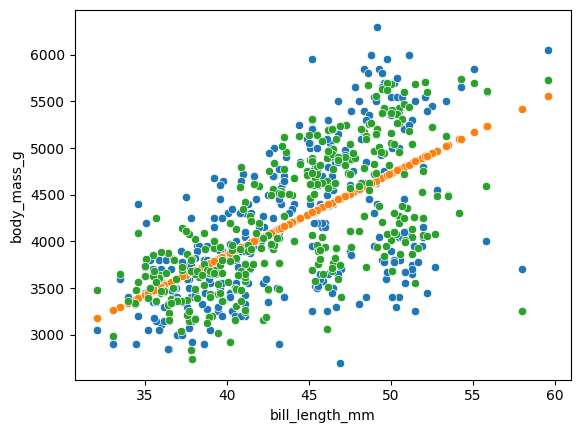

In [26]:
sns.scatterplot(x=X_train["bill_length_mm"], y=Y_train)
sns.scatterplot(x=X_train["bill_length_mm"], y=Y_pred2) # 1 feature variable model
sns.scatterplot(x=X_train["bill_length_mm"], y=Y_pred) # 3 feature variables model